# Results and Interpretation

Consolidated report for the CMP4336 bike-sharing demand project. It pulls together the model comparison, the best model's out-of-sample error analysis, and the feature-importance story, and reads them against the proposal's three questions: **environmental impact**, **temporal patterns**, and the **sequential-data** objective. All numbers come from `reports/metrics.json` and the processed data; the prose summary lives in `reports/RESULTS.md`. Metrics are reported as a set (RMSLE, RMSE, MAE, R²) and interpreted together.

## Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config
from bike_sharing.data import load_raw_train
from bike_sharing.features import build_features
from bike_sharing.models import get_model
from bike_sharing.preprocessing import drop_leakage_columns
from bike_sharing.evaluate import report
from bike_sharing.train import day_of_month_holdout_split

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
REPORTS_DIR = Path(CFG["paths"]["reports_dir"])
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
metrics = json.loads((REPORTS_DIR / "metrics.json").read_text())

sns.set_theme(context="notebook", style="whitegrid")
print("models evaluated:", sorted(metrics))


models evaluated: ['gradient_boosting', 'hourly_mean_baseline', 'mean_baseline', 'random_forest', 'ridge', 'xgboost']


## 1. Model comparison

Two leakage-safe validation views per model: chronological `TimeSeriesSplit(5)` (forecast future months) and the day-of-month holdout (train days 1-15, validate days 16-19), which mirrors the dataset's own train/test structure. Sorted by holdout RMSLE; lower is better for RMSLE/RMSE/MAE, higher for R².

In [2]:
# Full comparison: every model, both leakage-safe validation views, all
# four metrics read together (no single deciding score).
rows = []
for name, summary in metrics.items():
    cv = summary["cv"]["mean"]
    ho = summary["day_of_month_holdout"]["metrics"]
    rows.append({
        "model": name,
        "holdout_rmsle": ho["rmsle"], "holdout_rmse": ho["rmse"],
        "holdout_mae": ho["mae"], "holdout_r2": ho["r2"],
        "cv_rmsle": cv["rmsle"], "cv_rmse": cv["rmse"],
        "cv_mae": cv["mae"], "cv_r2": cv["r2"],
    })
leaderboard = pd.DataFrame(rows).set_index("model").sort_values("holdout_rmsle")
leaderboard.round(3)


,holdout_rmsle,holdout_rmse,holdout_mae,holdout_r2,cv_rmsle,cv_rmse,cv_mae,cv_r2
model,,,,,,,,
xgboost,0.309,46.459,27.615,0.936,0.447,78.663,52.897,0.769
random_forest,0.330,51.865,30.366,0.920,0.514,97.376,67.176,0.659
gradient_boosting,0.334,59.005,36.508,0.896,0.471,91.881,61.129,0.703
hourly_mean_baseline,0.755,125.884,86.065,0.527,0.739,142.972,99.341,0.348
ridge,0.905,162.224,106.179,0.214,0.987,168.895,115.232,0.109
mean_baseline,1.531,183.077,142.644,-0.001,1.402,196.381,149.341,-0.206


## 2. Best model — out-of-sample error analysis

The strongest model is refit on the early days of each month and scored on the later days it never saw, so the residuals below are honest generalization errors, not in-sample artifacts.

In [3]:
# Pick the best model by day-of-month holdout RMSLE (the more realistic
# view), then rebuild its out-of-sample predictions: fit on days 1-15,
# predict on the held-out days 16-19 it never saw. These residuals are a
# genuine generalization view for the error analysis below.
best_name = leaderboard.index[0]
print("best model by holdout RMSLE:", best_name)

train = drop_leakage_columns(build_features(load_raw_train(CFG), CFG), CFG)
y = train["count"].to_numpy(float)
dt = train[CFG["datetime_col"]]
X = train.drop(columns=["count", CFG["datetime_col"]])

tr_idx, ho_idx = day_of_month_holdout_split(dt)
best = get_model(best_name, CFG).fit(X.iloc[tr_idx], y[tr_idx])
y_true = y[ho_idx]
y_pred = best.predict(X.iloc[ho_idx])

err = X.iloc[ho_idx].copy()
err["actual"] = y_true
err["pred"] = y_pred
err["residual"] = y_pred - y_true
print("holdout report:", {k: round(v, 3) for k, v in report(y_true, y_pred).items()})


best model by holdout RMSLE: xgboost
holdout report: {'rmsle': 0.325, 'rmse': 47.968, 'mae': 29.201, 'r2': 0.931}


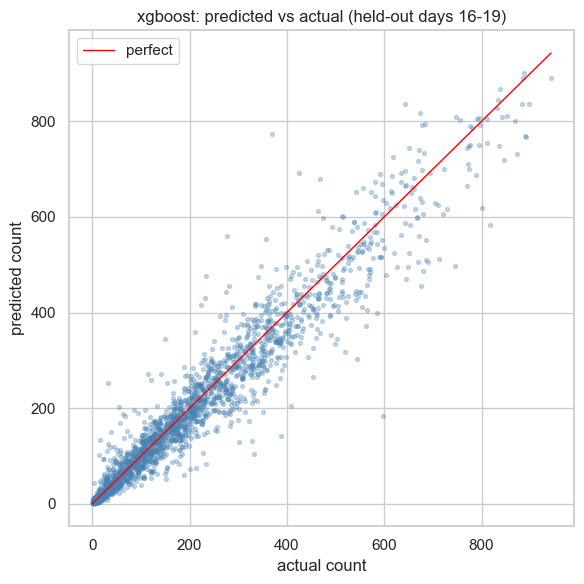

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(err["actual"], err["pred"], s=8, alpha=0.3, color="steelblue")
lim = max(err["actual"].max(), err["pred"].max())
ax.plot([0, lim], [0, lim], color="red", linewidth=1, label="perfect")
ax.set_title(f"{best_name}: predicted vs actual (held-out days 16-19)")
ax.set_xlabel("actual count")
ax.set_ylabel("predicted count")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "14_best_model_pred_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()


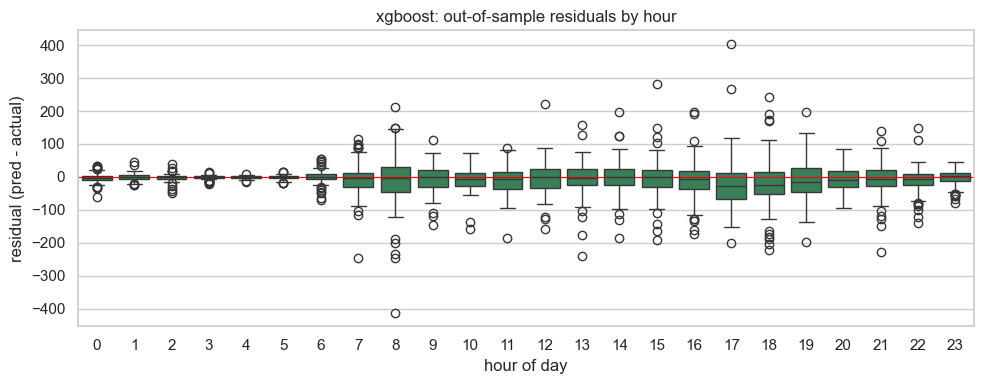

In [5]:
# Residuals by hour. Contrast with Ridge's residuals in notebook 03:
# the tree model's errors should hug zero across the whole day, showing
# it captured the bimodal commuter pattern the linear model missed.
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=err, x="hour", y="residual", color="seagreen", ax=ax)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_title(f"{best_name}: out-of-sample residuals by hour")
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (pred - actual)")
fig.tight_layout()
fig.savefig(FIG_DIR / "15_best_model_residuals_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Environmental error analysis

Where does the model err under different weather and seasonal conditions? This is the environmental-impact lens on the errors.

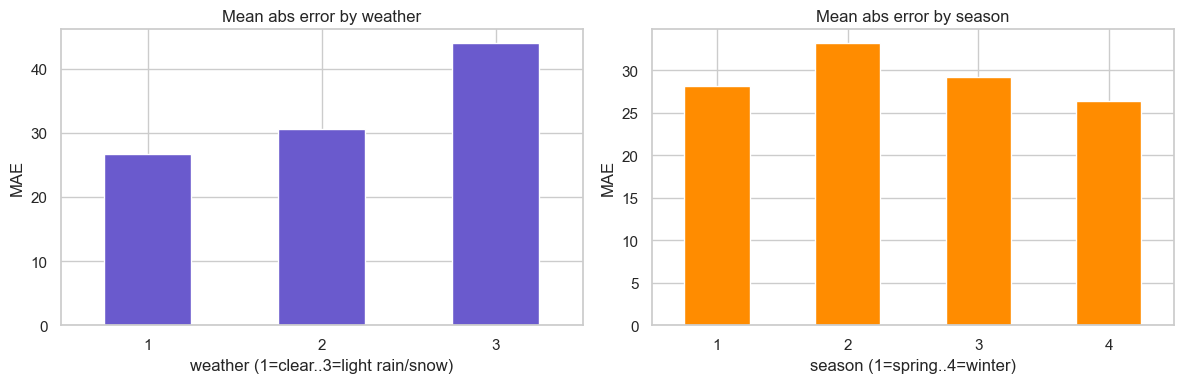

,mean,count
weather,,
1,26.70,1440
2,30.58,663
3,43.90,183


In [6]:
# Environmental error analysis: mean absolute error by weather category
# and by season. Shows whether the model degrades in adverse conditions
# (the environmental-impact question from the proposal).
err["abs_error"] = err["residual"].abs()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_weather = err.groupby("weather")["abs_error"].mean()
by_weather.plot(kind="bar", color="slateblue", ax=axes[0])
axes[0].set_title("Mean abs error by weather")
axes[0].set_xlabel("weather (1=clear..3=light rain/snow)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=0)

by_season = err.groupby("season")["abs_error"].mean()
by_season.plot(kind="bar", color="darkorange", ax=axes[1])
axes[1].set_title("Mean abs error by season")
axes[1].set_xlabel("season (1=spring..4=winter)")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "16_error_by_environment.png", dpi=120, bbox_inches="tight")
plt.show()
err.groupby("weather")["abs_error"].agg(["mean", "count"]).round(2)


## 4. Interpretation

**Temporal patterns (primary signal).** Demand is driven first by time-of-day, and the shape differs sharply between working and non-working days (the bimodal commuter peak vs a single afternoon peak). Linear models with first-harmonic cyclic features could not represent two peaks per day and lost to the trivial hour-of-day average; the tree/boosting models captured the `hour × workingday` interaction non-linearly and roughly halved the error. Feature importance confirms `hour` (and its cyclic encodings), `workingday`, and `year` dominate.

**Environmental impact (secondary signal).** Temperature, humidity, weather category, and season form a real but secondary tier: they modulate demand around the dominant daily rhythm rather than setting it, and the per-condition error analysis above shows where the model is least certain. This matches the EDA: demand rises with temperature and falls with humidity and worse weather.

**Sequential-data objective.** The proposal raised a sequential-analysis goal (target lags such as `count(t-1)`). We deliberately did **not** add target-lag features: the test set covers later days with no observed counts, so a lag feature cannot be built at inference time without true future targets, and would leak during validation. The temporal signal is instead captured through calendar and cyclic features. A leakage-safe sequential experiment would require recursive multi-step generation at inference and a matching recursive validation protocol; it is scoped as optional future work, documented before any code per the experiment-log rules.

**Model choice.** XGBoost is narrowly the strongest on both views, but Random Forest and Gradient Boosting are close; the three should be read as a near-tie rather than a decisive winner. The hour-of-day mean is a remarkably strong, interpretable baseline that any added complexity must beat - and only the non-linear models do.

**Limitations.** Hyperparameters are sensible defaults, not tuned; importances are impurity-based (a diagnostic, not causal); and `day`-of-month was excluded because train and test do not overlap on it. See `reports/RESULTS.md` for the written summary.